Ranked/classic match sayısı: 113254
Summoner + match birleşmiş satır sayısı: 125001

FINAL DATA HEAD:
   SummonerMatchId  SummonerFk          MatchFk           Patch QueueType  \
0                1           1  EUW1_7565751492  15.20.717.2831   CLASSIC   
1                2           1  EUW1_7565549583  15.20.717.2831   CLASSIC   
2                3           1  EUW1_7564803077  15.20.717.2831   CLASSIC   
3                7           1  EUW1_7564257986  15.20.717.2831   CLASSIC   
4                8           1  EUW1_7563685543  15.20.717.2831   CLASSIC   

   GameDuration  RankFk RankName  ChampionFk ChampionName  Win  IsBlue  IsRed  
0          1751       7  Diamond         902        Milio    0    True  False  
1          2092       7  Diamond         902        Milio    0   False   True  
2          2332       7  Diamond          16       Soraka    1   False   True  
3          1676       7  Diamond         902        Milio    0   False   True  
4          1749       7  Diamond   

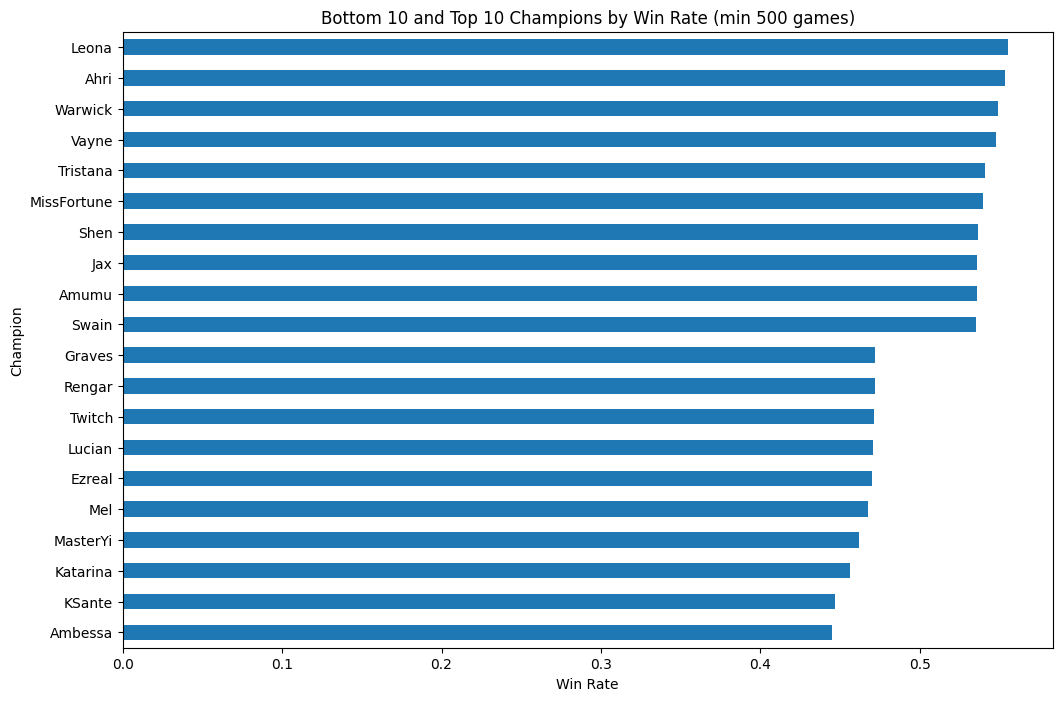

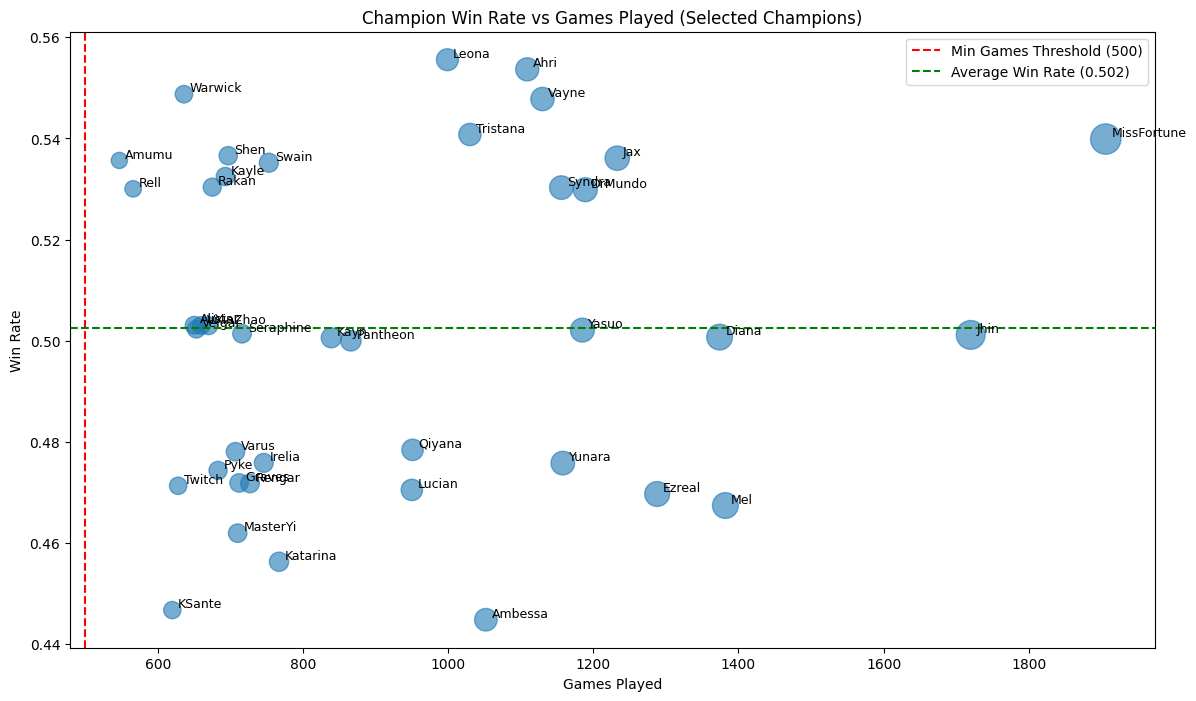


Meta distribution:
Meta
False    98320
True     26681
Name: count, dtype: int64

Meta vs Rank Win Rates:
             Non-Meta Champion  Meta Champion
RankName                                     
Iron                  0.469312       0.500000
Bronze                0.488918       0.542002
Silver                0.485141       0.541752
Gold                  0.490368       0.529878
Platinum              0.494022       0.539152
Emerald               0.500590       0.554932
Diamond               0.470150       0.502116
Master                0.508646       0.545455
Grandmaster           0.508779       0.583196
Challenger            0.524079       0.558333


<Figure size 1000x600 with 0 Axes>

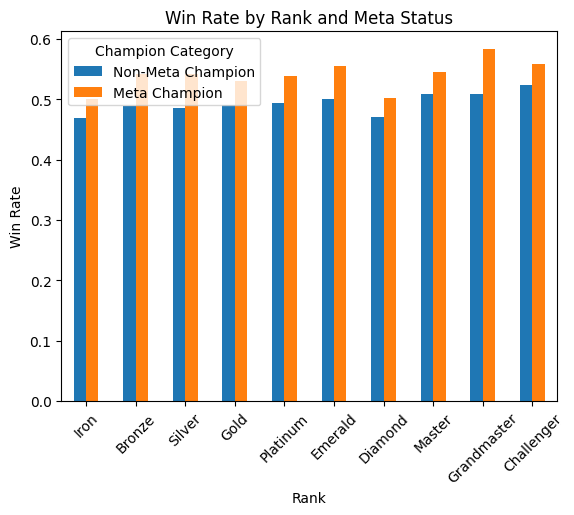


Meta advantage by rank:
RankName
Iron           0.030688
Bronze         0.053084
Silver         0.056610
Gold           0.039509
Platinum       0.045131
Emerald        0.054342
Diamond        0.031967
Master         0.036808
Grandmaster    0.074417
Challenger     0.034254
Name: Difference, dtype: float64


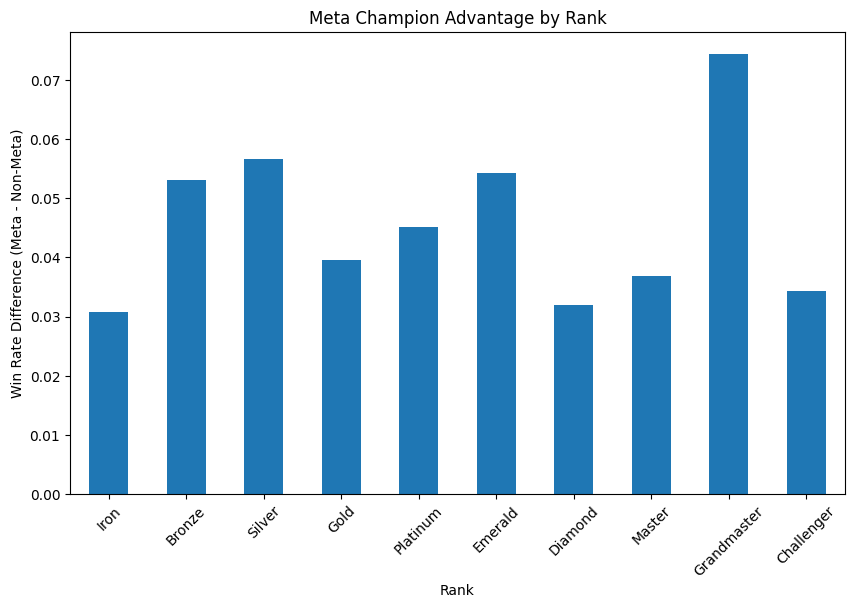


Meta sample sizes:
High elo meta sample: 11701
Low elo meta sample: 7491

T-test result:
T-statistic: -0.22101749789463754
P-value: 0.825081635078736
Result: No statistically significant difference found between high elo and low elo meta champion win rates.


In [20]:
# DSA 210 Project
# League of Legends Meta Analysis
# Name: [Taha Ünal]

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# =========================
# 1) CSV DOSYALARINI OKU
# =========================
summoner = pd.read_csv("/content/SummonerMatchTbl.csv")
champ = pd.read_csv("/content/ChampionTbl.csv")
rank = pd.read_csv("/content/RankTbl.csv")
match = pd.read_csv("/content/MatchTbl.csv")
team = pd.read_csv("/content/TeamMatchTbl.csv")

# =========================
# 2) MATCH + TEAM MERGE
# =========================
merged_match = match.merge(team, left_on="MatchId", right_on="MatchFk", how="inner")

# =========================
# 3) SADECE RANKED / CLASSIC MAÇLARI AL
# =========================
merged_match = merged_match[
    (merged_match["QueueType"] == "CLASSIC") &
    (merged_match["RankFk"] != 0)
].copy()

print("Ranked/classic match sayısı:", len(merged_match))

# =========================
# 4) SUMMONER İLE MERGE
# =========================
player_df = summoner.merge(
    merged_match,
    left_on="MatchFk",
    right_on="MatchId",
    how="inner"
)

print("Summoner + match birleşmiş satır sayısı:", len(player_df))

# =========================
# 5) CHAMPION ADINI EKLE
# =========================
player_df = player_df.merge(
    champ,
    left_on="ChampionFk",
    right_on="ChampionId",
    how="left"
)

# =========================
# 6) OYUNCUNUN MAVİ Mİ KIRMIZI MI OLDUĞUNU BUL
# =========================
blue_cols = ["B1Champ", "B2Champ", "B3Champ", "B4Champ", "B5Champ"]
red_cols = ["R1Champ", "R2Champ", "R3Champ", "R4Champ", "R5Champ"]

player_df["IsBlue"] = player_df.apply(
    lambda row: row["ChampionFk"] in [row[col] for col in blue_cols],
    axis=1
)

player_df["IsRed"] = player_df.apply(
    lambda row: row["ChampionFk"] in [row[col] for col in red_cols],
    axis=1
)

# =========================
# 7) WIN SÜTUNU ÜRET
# =========================
player_df["Win"] = np.where(
    player_df["IsBlue"],
    player_df["BlueWin"],
    np.where(player_df["IsRed"], player_df["RedWin"], np.nan)
)

# =========================
# 8) RANK ADINI EKLE
# =========================
player_df = player_df.merge(
    rank,
    left_on="RankFk",
    right_on="RankId",
    how="left"
)

if "MatchFk_x" in player_df.columns:
    player_df = player_df.rename(columns={"MatchFk_x": "MatchFk"})

# =========================
# 9) FINAL DATASET OLUŞTUR
# =========================
final_df = player_df[[
    "SummonerMatchId",
    "SummonerFk",
    "MatchFk",
    "Patch",
    "QueueType",
    "GameDuration",
    "RankFk",
    "RankName",
    "ChampionFk",
    "ChampionName",
    "Win",
    "IsBlue",
    "IsRed"
]].copy()

final_df = final_df.dropna(subset=["Win", "ChampionName", "RankName"])
final_df["Win"] = final_df["Win"].astype(int)

print("\nFINAL DATA HEAD:")
print(final_df.head())

print("\nFINAL DATA SHAPE:")
print(final_df.shape)

print("\nRANK DISTRIBUTION:")
print(final_df["RankName"].value_counts())

# =========================
# 10) CHAMPION İSTATİSTİKLERİ
# =========================
champ_stats = final_df.groupby("ChampionName").agg(
    WinRate=("Win", "mean"),
    GamesPlayed=("Win", "count")
).sort_values("WinRate", ascending=False)

print("\nChampion stats head:")
print(champ_stats.head())

# =========================
# 11) GÜVENİLİR CHAMPION ANALİZİ
# min 500 games
# =========================
reliable_champs = champ_stats[champ_stats["GamesPlayed"] >= 500].copy()
reliable_champs = reliable_champs.sort_values("WinRate")

print("\nReliable champions count:", len(reliable_champs))

# Bottom 10 + Top 10
top_bottom = pd.concat([
    reliable_champs.head(10),
    reliable_champs.tail(10)
])

plt.figure(figsize=(12, 8))
top_bottom["WinRate"].plot(kind="barh")
plt.title("Bottom 10 and Top 10 Champions by Win Rate (min 500 games)")
plt.xlabel("Win Rate")
plt.ylabel("Champion")
plt.show()

# =========================
# 12) PROFESYONEL SCATTER PLOT
# seçilmiş championlar + etiketler
# =========================
champ_scatter = champ_stats.reset_index()

filtered_scatter = champ_scatter[champ_scatter["GamesPlayed"] >= 500].copy()

top_15 = filtered_scatter.sort_values("WinRate", ascending=False).head(15)
bottom_15 = filtered_scatter.sort_values("WinRate", ascending=True).head(15)

median_win = filtered_scatter["WinRate"].median()
middle_10 = filtered_scatter.iloc[
    (filtered_scatter["WinRate"] - median_win).abs().argsort()[:10]
]

selected_scatter = pd.concat([top_15, bottom_15, middle_10]).drop_duplicates()

avg_winrate = filtered_scatter["WinRate"].mean()

plt.figure(figsize=(14, 8))

plt.scatter(
    selected_scatter["GamesPlayed"],
    selected_scatter["WinRate"],
    s=selected_scatter["GamesPlayed"] / 4,
    alpha=0.6
)

plt.axvline(x=500, color="red", linestyle="--", label="Min Games Threshold (500)")
plt.axhline(y=avg_winrate, color="green", linestyle="--", label=f"Average Win Rate ({avg_winrate:.3f})")

for _, row in selected_scatter.iterrows():
    plt.text(
        row["GamesPlayed"] + 8,
        row["WinRate"] + 0.0005,
        row["ChampionName"],
        fontsize=9
    )

plt.title("Champion Win Rate vs Games Played (Selected Champions)")
plt.xlabel("Games Played")
plt.ylabel("Win Rate")
plt.legend()
plt.show()

# =========================
# 13) META TANIMI
# Champion ortalama winrate > 0.52
# =========================
final_df["ChampionWinRate"] = final_df.groupby("ChampionName")["Win"].transform("mean")
final_df["Meta"] = final_df["ChampionWinRate"] > 0.52

print("\nMeta distribution:")
print(final_df["Meta"].value_counts())

rank_order = [
    "Iron", "Bronze", "Silver", "Gold", "Platinum",
    "Emerald", "Diamond", "Master", "Grandmaster", "Challenger"
]

# =========================
# 14) RANK + META KARŞILAŞTIRMA
# =========================
meta_vs_rank = final_df.groupby(["RankName", "Meta"])["Win"].mean().unstack()
meta_vs_rank = meta_vs_rank.reindex(rank_order)
meta_vs_rank.columns = ["Non-Meta Champion", "Meta Champion"]

print("\nMeta vs Rank Win Rates:")
print(meta_vs_rank)

plt.figure(figsize=(10, 6))
meta_vs_rank.plot(kind="bar")
plt.title("Win Rate by Rank and Meta Status")
plt.ylabel("Win Rate")
plt.xlabel("Rank")
plt.xticks(rotation=45)
plt.legend(title="Champion Category")
plt.show()

# =========================
# 15) META AVANTAJI GRAFİĞİ
# Meta - Non-Meta farkı
# =========================
meta_diff = final_df.groupby(["RankName", "Meta"])["Win"].mean().unstack()
meta_diff = meta_diff.reindex(rank_order)

meta_diff["Difference"] = meta_diff[True] - meta_diff[False]

print("\nMeta advantage by rank:")
print(meta_diff["Difference"])

plt.figure(figsize=(10, 6))
meta_diff["Difference"].plot(kind="bar")
plt.title("Meta Champion Advantage by Rank")
plt.ylabel("Win Rate Difference (Meta - Non-Meta)")
plt.xlabel("Rank")
plt.xticks(rotation=45)
plt.show()

# =========================
# 16) HYPOTHESIS TEST
# High elo vs low elo meta champion winrate
# =========================
high_elo = final_df[final_df["RankName"].isin(["Diamond", "Master", "Grandmaster", "Challenger"])]
low_elo = final_df[final_df["RankName"].isin(["Bronze", "Silver", "Gold"])]

meta_high = high_elo[high_elo["Meta"] == True]["Win"]
meta_low = low_elo[low_elo["Meta"] == True]["Win"]

print("\nMeta sample sizes:")
print("High elo meta sample:", len(meta_high))
print("Low elo meta sample:", len(meta_low))

t_stat, p_value = ttest_ind(meta_high, meta_low, equal_var=False)

print("\nT-test result:")
print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Statistically significant difference exists between high elo and low elo meta champion win rates.")
else:
    print("Result: No statistically significant difference found between high elo and low elo meta champion win rates.")